# Stillaguamish Low Lows Investigation
Why do the low lows of tides not propagate to the gage?

I will start by just plotting the bathymetry, quadtree mesh, and a line segment near the gage

In [7]:
import numpy as np
import utm
     
lon0 = -122.33893946827288
lat0 = 48.21209714949339
lon1 = -122.33914560295707
lat1 = 48.20899814616419

x0, y0, _, __ = utm.from_latlon(lat0, lon0)
x1, y1, _, __ = utm.from_latlon(lat1, lon1)

xrange = np.linspace(x0, x1, 50)
yrange = np.linspace(y0, y1, 50)

In [8]:
import xarray as xr

qtr_file = '/home/cassandra/Snohomish/2026-03-12-stillaguamish/sfincs.nc'
sbg_file = '/home/cassandra/Snohomish/2026-03-12-stillaguamish/sfincs.sbg'
his_file = '/home/cassandra/Snohomish/2026-03-12-stillaguamish/benchmark_dry/sfincs_his.nc'
map_file = '/home/cassandra/Snohomish/2026-03-12-stillaguamish/benchmark_dry/sfincs_map.nc'

qtr = xr.open_dataset(qtr_file)

# Quadtree nodes
bx = qtr.mesh2d_node_x.values
by = qtr.mesh2d_node_y.values
i = qtr.mesh2d_face_nodes.values.astype(int)
lev = qtr.level.values

# Get the grid spacing
qdx = qtr.dx / (2** (lev - 1))
qdy = qtr.dy / (2** (lev - 1))

# Get the bottom left corners
x0, y0 = [], []
for j in range(len(i)):
    x0.append(bx[i[j][0]])
    y0.append(by[i[j][0]])
x0 = np.array(x0)
y0 = np.array(y0)

# Get the centers
xc = x0 + qdx/2
yc = y0 + qdy/2

/tmp/ipykernel_342477/878133071.py:13: RuntimeWarning: invalid value encountered in cast
  i = qtr.mesh2d_face_nodes.values.astype(int)


In [16]:
DEM_path = '/home/cassandra/Data/Stilly_DemMod_03_05_2026/Stillaguamish_Transects/CoNED_StillyFull_dredge_v1.tif'
DEM = xr.open_dataset(DEM_path)

dem_dx = DEM.x[1] - DEM.x[0]
dem_dy = DEM.y[1] - DEM.y[0]

In [ ]:
import matplotlib.pyplot as plt

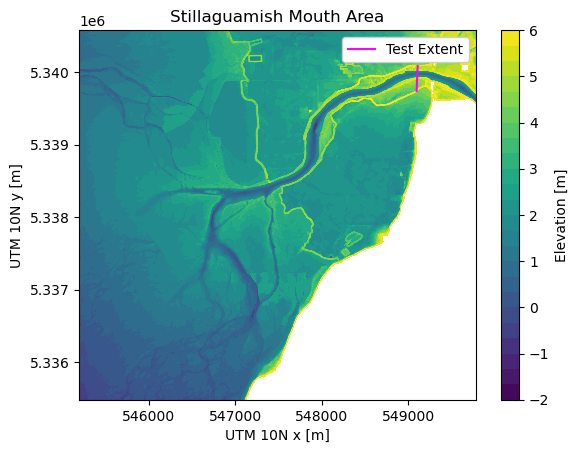

In [50]:
lon_min = -122.39208226847964
lat_min =  48.170949455172604
lon_max = -122.3298161801093
lat_max = 48.21649583106796

x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)\

xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )
yif = int( (y_min - DEM.y[0]) / dem_dy )

dem_x = DEM.x[xi0:xif]
dem_y = DEM.y[yi0:yif]
dem_z = DEM.band_data[0, yi0:yif, xi0:xif]

plt.figure()
plt.title("Stillaguamish Mouth Area")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25))
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.plot(xrange, yrange, color='magenta', label='Test Extent')
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### Since plotting a mesh sounds like a lot of work, and I am only using the quadtree grid cell centers, plot the centers and make sure it looks reasonable...

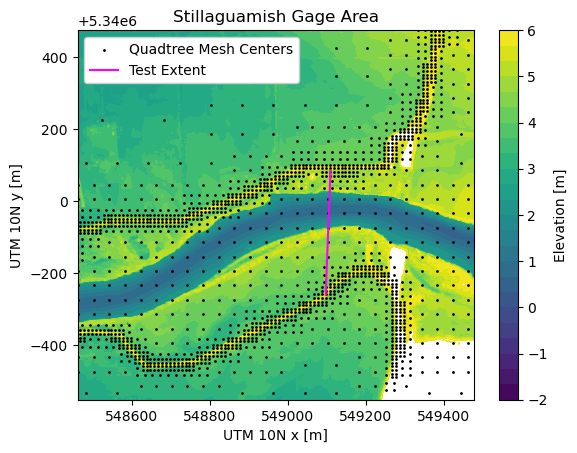

In [48]:
lon_min = -122.34774099619244
lat_min =  48.206422008195034
lon_max = -122.33393149162369
lat_max = 48.215575391284375

x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)

xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )
yif = int( (y_min - DEM.y[0]) / dem_dy )

dem_x = DEM.x[xi0:xif]
dem_y = DEM.y[yi0:yif]
dem_z = DEM.band_data[0, yi0:yif, xi0:xif]

plt.figure()
plt.title("Stillaguamish Gage Area")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25))
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.scatter(xc, yc, s=1, color='black', label='Quadtree Mesh Centers')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.plot(xrange, yrange, color='magenta', label='Test Extent')
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### Across the line, let's test that I can correctly index from points along the line segment to quadtree mesh centers using my standard code snippet...

In [58]:
# Quadtree nodes
bx = qtr.mesh2d_node_x.values
by = qtr.mesh2d_node_y.values
i = qtr.mesh2d_face_nodes.values.astype(int)
lev = qtr.level.values

# Get the grid spacing
qdx = qtr.dx / (2** (lev - 1))
qdy = qtr.dy / (2** (lev - 1))

# Get the bottom left corners
x0, y0 = [], []
for j in range(len(i)):
    x0.append(bx[i[j][0]])
    y0.append(by[i[j][0]])
x0 = np.array(x0)
y0 = np.array(y0)

# Get the centers
xc = x0 + qdx/2
yc = y0 + qdy/2

def xy_to_quadtree_index(x, y):
    # Return index to nearest grid center
    dist = np.sqrt((xc - x)**2 + (yc - y)**2)
    return np.argmin(dist)    

/tmp/ipykernel_342477/2465598796.py:5: RuntimeWarning: invalid value encountered in cast
  i = qtr.mesh2d_face_nodes.values.astype(int)


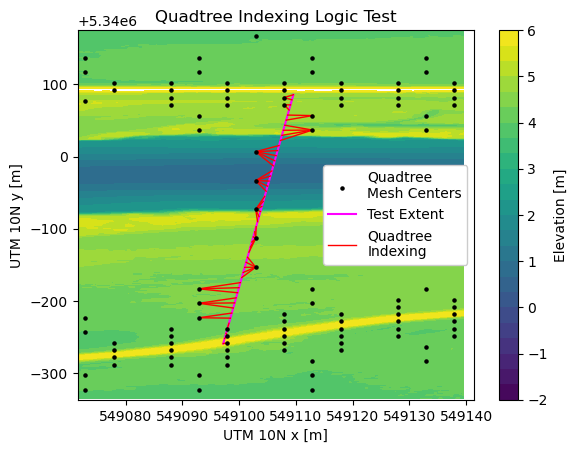

In [65]:
lon_min = -122.3395
lat_min =   48.2083
lon_max = -122.3385
lat_max =   48.2129

x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)

xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )
yif = int( (y_min - DEM.y[0]) / dem_dy )

dem_x = DEM.x[xi0:xif]
dem_y = DEM.y[yi0:yif]
dem_z = DEM.band_data[0, yi0:yif, xi0:xif]

plt.figure()
plt.title("Quadtree Indexing Logic Test")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25))
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.scatter(xc, yc, s=5, color='black', label='Quadtree\nMesh Centers', zorder=5)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.plot(xrange, yrange, color='magenta', label='Test Extent')
for x,y in zip(xrange, yrange):
    i = xy_to_quadtree_index(x, y)
    plt.plot([x, xc[i]], [y, yc[i]], color='red', linewidth=1)
plt.axvline(np.nan, color='red', linewidth=1, label='Quadtree\nIndexing')
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### Seems good -- I am betting my quadtree indexing code is not the problem. Let's see what the water level was doing from offshore to onshore. To do that, I need the channel polygon...

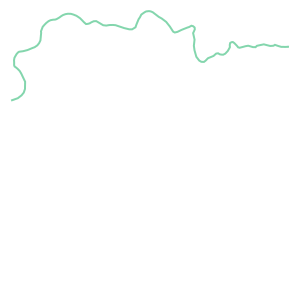

In [81]:
import geopandas as gpd
channels = gpd.read_file('/home/cassandra/Snohomish/2026-03-12-stillaguamish/obs_channels.geojson').set_crs('EPSG:4326').to_crs('EPSG:32610')
main_chan = channels.geometry[0]
main_chan

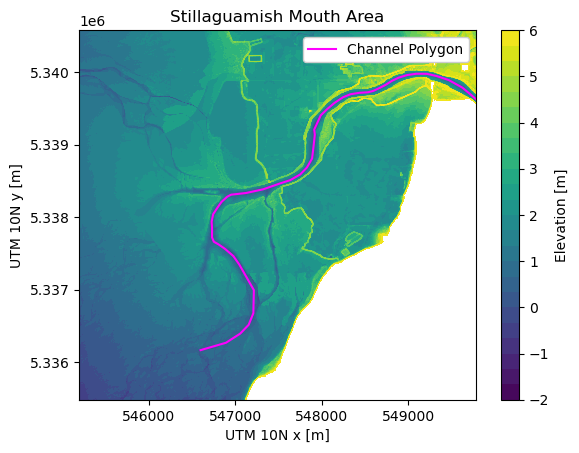

In [88]:
lon_min = -122.39208226847964
lat_min =  48.170949455172604
lon_max = -122.3298161801093
lat_max = 48.21649583106796

x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)\

xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )
yif = int( (y_min - DEM.y[0]) / dem_dy )

dem_x = DEM.x[xi0:xif]
dem_y = DEM.y[yi0:yif]
dem_z = DEM.band_data[0, yi0:yif, xi0:xif]

plt.figure()
plt.title("Stillaguamish Mouth Area")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25))
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.plot(main_chan.xy[0], main_chan.xy[1], color='magenta', label='Channel Polygon')
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### Now assured that I can properly load and plot the channel polygon, let's sample the polygon in regular 100m segments and point those to quadtree meshes....

In [144]:
d = np.arange(0, 8000, 100)
points = [main_chan.interpolate(dd) for dd in d]
quad_i = np.array([xy_to_quadtree_index(point.xy[0][0], point.xy[1][0]) for point in points])
quad_x, quad_y = xc[quad_i], yc[quad_i]

/tmp/ipykernel_342477/2465598796.py:5: RuntimeWarning: invalid value encountered in cast
  i = qtr.mesh2d_face_nodes.values.astype(int)


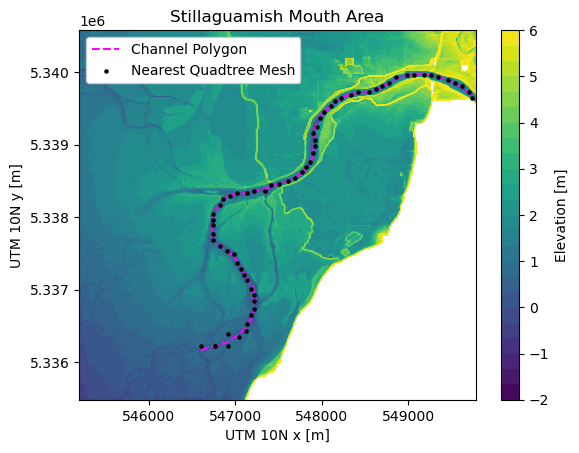

In [150]:
plt.figure()
plt.title("Stillaguamish Mouth Area")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25))
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.plot(main_chan.xy[0], main_chan.xy[1], color='magenta', label='Channel Polygon', linestyle='--', zorder=4)
plt.scatter(quad_x, quad_y, color='black', label='Nearest Quadtree Mesh', s=5, zorder=5)
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### How about in close vicinity to the gage...

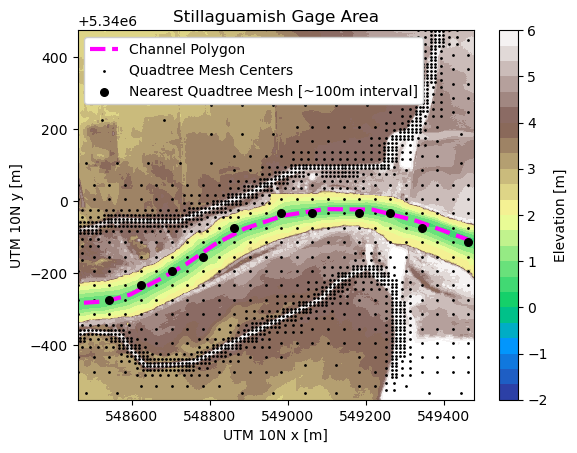

In [174]:
lon_min = -122.34774099619244
lat_min =  48.206422008195034
lon_max = -122.33393149162369
lat_max = 48.215575391284375

x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)

xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )
yif = int( (y_min - DEM.y[0]) / dem_dy )

dem_x = DEM.x[xi0:xif]
dem_y = DEM.y[yi0:yif]
dem_z = DEM.band_data[0, yi0:yif, xi0:xif]

plt.figure()
plt.title("Stillaguamish Gage Area")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25), cmap='terrain')
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.plot(main_chan.xy[0], main_chan.xy[1], color='magenta', label='Channel Polygon', linestyle='--', zorder=4, linewidth=3)
plt.scatter(xc, yc, s=1, color='black', label='Quadtree Mesh Centers')
plt.scatter(quad_x, quad_y, color='black', label='Nearest Quadtree Mesh [~100m interval]', s=30, zorder=5)
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

### Good! Now accessing the sfincs map output from the benchmark... let's see the Hovmoller diagram

In [146]:
out = xr.open_dataset(map_file)
zs  = out.zs[:, quad_i].values

In [147]:
eta = zs - np.nanmedian(zs, axis=0)

/home/cassandra/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


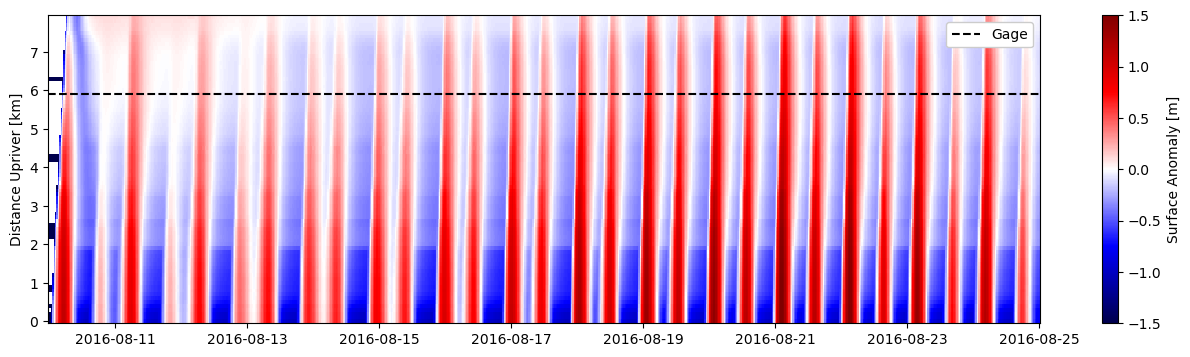

In [149]:
close_lat, close_lon = 48.210927, -122.337067
cx, cy, _, __ = utm.from_latlon(close_lat, close_lon)
i = np.argmin(np.sqrt((quad_x - cx)**2 + (quad_y - cy)**2))

fig = plt.figure(figsize=(16, 4))
m = plt.pcolormesh(out.time, d/1000, eta.T, vmin=-1.5, vmax=1.5, cmap='seismic')
cb = plt.colorbar(m)
cb.ax.set_ylabel("Surface Anomaly [m]")
plt.ylabel("Distance Upriver [km]")
plt.axhline(d[i]/1000, label='Gage', color='black', linestyle='--')
plt.legend(framealpha=1)
plt.show()

### Before going forward, let's check against the gage data, for sanity. 

In [ ]:
gage = xr.open_dataset('/home/cassandra/Data/stillaguamish_gage/stillaguamish_continous.nc')
gage

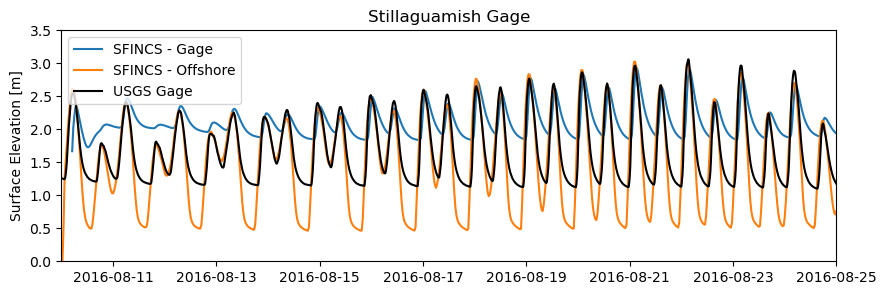

In [164]:
plt.figure(figsize=(10, 3))
plt.plot(out.time, zs[:,i], label='SFINCS - Gage')
plt.plot(out.time, zs[:,0], label='SFINCS - Offshore')
plt.plot(gage.time, gage.stage[0], label='USGS Gage', color='black')
plt.xlim(out.time[0], out.time[-1])
plt.ylim(0, 3.5)
plt.title("Stillaguamish Gage")
plt.ylabel("Surface Elevation [m]")
plt.legend()
plt.show()

### Seems like several progressive steps where low lows don't propagate any further -- around 2, 2.6, and 3.3 km in...

/home/cassandra/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


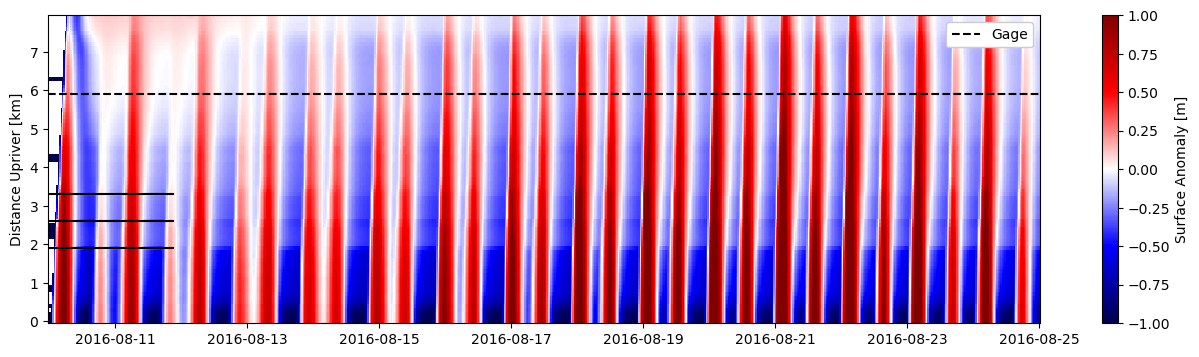

In [193]:
fig = plt.figure(figsize=(16, 4))
m = plt.pcolormesh(out.time, d/1000, eta.T, vmin=-1.0, vmax=1.0, cmap='seismic')
cb = plt.colorbar(m)
cb.ax.set_ylabel("Surface Anomaly [m]")
plt.ylabel("Distance Upriver [km]")
plt.axhline(d[i]/1000, label='Gage', color='black', linestyle='--')
plt.plot(out.time[[0,int(len(out.time)/8)]], [1.9, 1.9], color='black')
plt.plot(out.time[[0,int(len(out.time)/8)]], [2.6, 2.6], color='black')
plt.plot(out.time[[0,int(len(out.time)/8)]], [3.3, 3.3], color='black')
plt.legend(framealpha=1)
plt.show()

### Let's plot where they are!

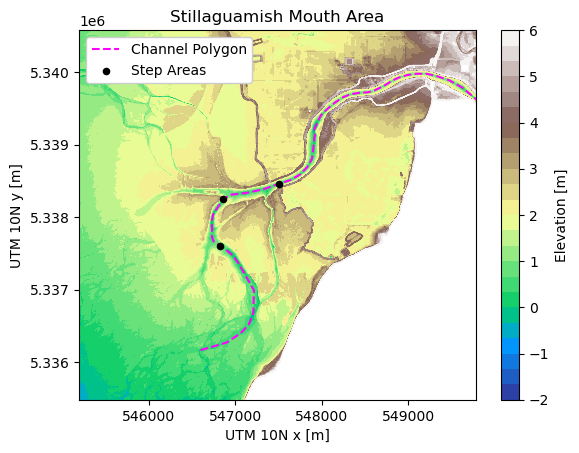

In [198]:
lon_min = -122.39208226847964
lat_min =  48.170949455172604
lon_max = -122.3298161801093
lat_max = 48.21649583106796

x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)

xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )
yif = int( (y_min - DEM.y[0]) / dem_dy )

dem_x = DEM.x[xi0:xif]
dem_y = DEM.y[yi0:yif]
dem_z = DEM.band_data[0, yi0:yif, xi0:xif]

plt.figure()
plt.title("Stillaguamish Mouth Area")
cf = plt.contourf(dem_x, dem_y, dem_z, levels=np.linspace(-2, 6, 25), cmap='terrain')
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Elevation [m]")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.plot(main_chan.xy[0], main_chan.xy[1], color='magenta', label='Channel Polygon', linestyle='--', zorder=4)
# plt.scatter(quad_x, quad_y, color='black', label='Nearest Quadtree Mesh', s=5, zorder=5)
plt.scatter(quad_x[[19, 26, 33]], quad_y[[19, 26, 33]], color='black', s=20, zorder=6, label='Step Areas')
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### Final test -- I'd like to plot the overal water surface elevation during one of these low lows. Let's see what that looks like...

/tmp/ipykernel_342477/257583517.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(framealpha=1)


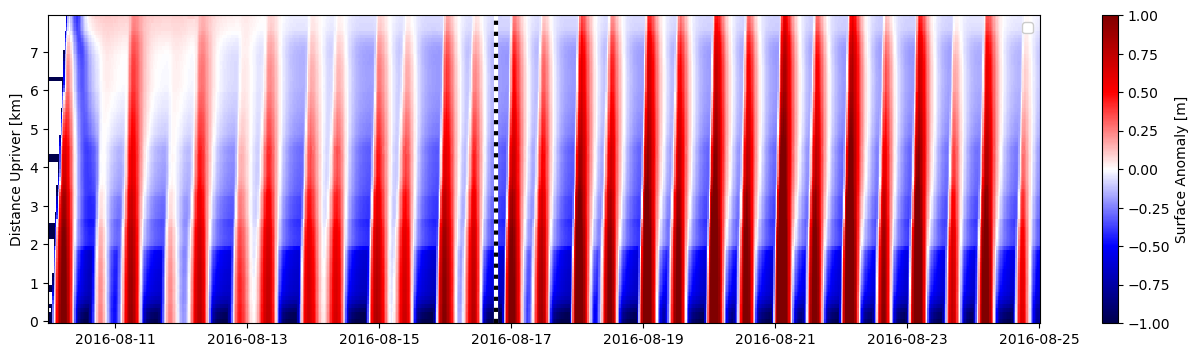

In [234]:
ti = 325

fig = plt.figure(figsize=(16, 4))
m = plt.pcolormesh(out.time, d/1000, eta.T, vmin=-1.0, vmax=1.0, cmap='seismic')
cb = plt.colorbar(m)
cb.ax.set_ylabel("Surface Anomaly [m]")
plt.ylabel("Distance Upriver [km]")
plt.axvline(out.time.values[ti], color='white', linewidth=3)
plt.axvline(out.time.values[ti], color='black', linewidth=3, linestyle=':')
plt.legend(framealpha=1)
plt.show()

### Let's check what that looks like in surface elevation units...

/home/cassandra/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


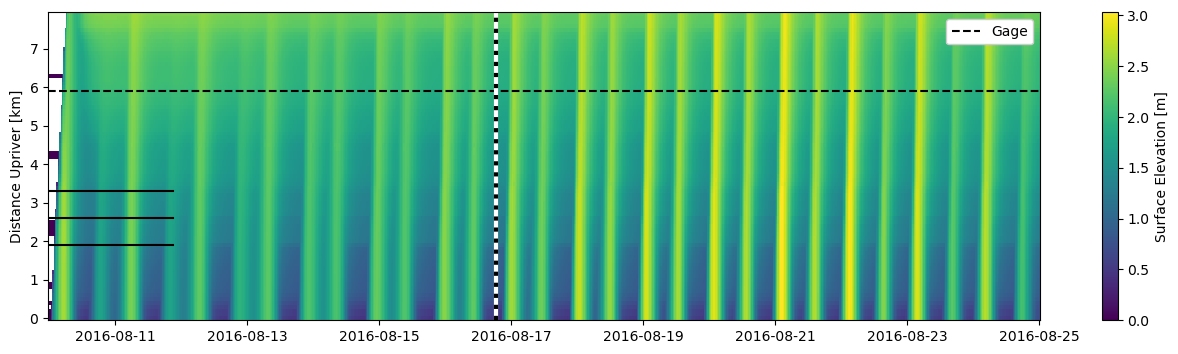

In [251]:
close_lat, close_lon = 48.210927, -122.337067
cx, cy, _, __ = utm.from_latlon(close_lat, close_lon)
i = np.argmin(np.sqrt((quad_x - cx)**2 + (quad_y - cy)**2))

ti = 325

fig = plt.figure(figsize=(16, 4))
m = plt.pcolormesh(out.time, d/1000, zs.T)
cb = plt.colorbar(m)
cb.ax.set_ylabel("Surface Elevation [m]")
plt.ylabel("Distance Upriver [km]")
plt.axhline(d[i]/1000, label='Gage', color='black', linestyle='--')
plt.plot(out.time[[0,int(len(out.time)/8)]], [1.9, 1.9], color='black')
plt.plot(out.time[[0,int(len(out.time)/8)]], [2.6, 2.6], color='black')
plt.plot(out.time[[0,int(len(out.time)/8)]], [3.3, 3.3], color='black')

plt.axvline(out.time.values[ti], color='white', linewidth=3)
plt.axvline(out.time.values[ti], color='black', linewidth=3, linestyle=':')

plt.legend(framealpha=1)
plt.show()

### Let's plot that time index, spatially!

In [203]:
# Load quadtree info
bx  = qtr.mesh2d_node_x.values
by  = qtr.mesh2d_node_y.values
i   = qtr.mesh2d_face_nodes.values.astype(int)
lev = qtr.level.values

# Get the grid spacing
qdx = qtr.dx / (2** (lev - 1))
qdy = qtr.dy / (2** (lev - 1))

# Get the bottom left corners
x0, y0 = [], []
for j in range(len(i)):
    x0.append(bx[i[j][0]])
    y0.append(by[i[j][0]])
x0 = np.array(x0)
y0 = np.array(y0)

/tmp/ipykernel_342477/2561925607.py:4: RuntimeWarning: invalid value encountered in cast
  i   = qtr.mesh2d_face_nodes.values.astype(int)


In [220]:
# Define a region in lat/lon
lon_min = -122.39208226847964
lat_min =  48.170949455172604
lon_max = -122.3298161801093
lat_max = 48.21649583106796

# Convert to bathy CRS (UTM)
x_min, y_min, _, __ = utm.from_latlon(lat_min, lon_min)
x_max, y_max, _, __ = utm.from_latlon(lat_max, lon_max)

# Get that subset of the bathy
xi0 = int( (x_min - DEM.x[0] ) / dem_dx )
xif = int( (x_max - DEM.x[0] ) / dem_dx )
yi0 = int( (y_max - DEM.y[0]) / dem_dy )  # Note y is flipped
yif = int( (y_min - DEM.y[0]) / dem_dy )

# Load that into memory
dem_x = DEM.x[xi0:xif].values
dem_y = DEM.y[yi0:yif].values
dem_z = DEM.band_data[0, yi0:yif, xi0:xif].values

# Get dx, dy
dem_dx = dem_x[1] - dem_x[0]
dem_dy = dem_y[0] - dem_y[1]  # note reversed!

In [221]:
# Because its small, simply load model output into memory...
ozs = out.zs.values

In [244]:
# For each quadtree grid cell, locate and assign the relevant bathy indices (point from bathy --> quadtree)
qi = np.int64(list(range(len(qtr.mesh2d_nFaces))))

# This is the range of BATHY indices each QUADTREE cell corresponds to for x...
xi0  = np.int64((x0       - dem_x[ 0]) / dem_dx)
xif  = np.int64((x0 + qdx - dem_x[ 0]) / dem_dx)

# ... and y
yi0t = np.int64((y0       - dem_y[-1]) / dem_dy)
yift = np.int64((y0 + qdy - dem_y[-1]) / dem_dy)
yif = -1 * yi0t + len(dem_y)  # Note y is flipped
yi0 = -1 * yift + len(dem_y)

# Check what intersects the area of interest -- full quadtree cells only
qok = np.logical_and(np.logical_and(xif >= 0, xi0 < len(dem_x)),
                     np.logical_and(yif >= 0, yi0 < len(dem_y)))

# Create empty array, same shape as DEM, to hold data
eta = np.zeros((len(dem_y), len(dem_x)))*np.nan

for i in qi[qok]:                                         # For each quadtree cell in the area of interest
    
    for xi in range(xi0[i],xif[i]):                       # For the range of bathy X indices this quadtree points to...
        if xi >= len(dem_x) or xi < 0: continue           # (skip if indices are out of range)
            
        for yi in range(yi0[i], yif[i]):                  # For the range of bathy Y indices this quadtree points to...
            if yi >= len(dem_y) or yi < 0: continue       # (skip if indices are out of range)
        
            eta[yi,xi] = ozs[ti,i]                        # Assign water level for each bathy index related to this quadtree cell

# Drop depths that are below ground
eta[eta < dem_z] = np.nan

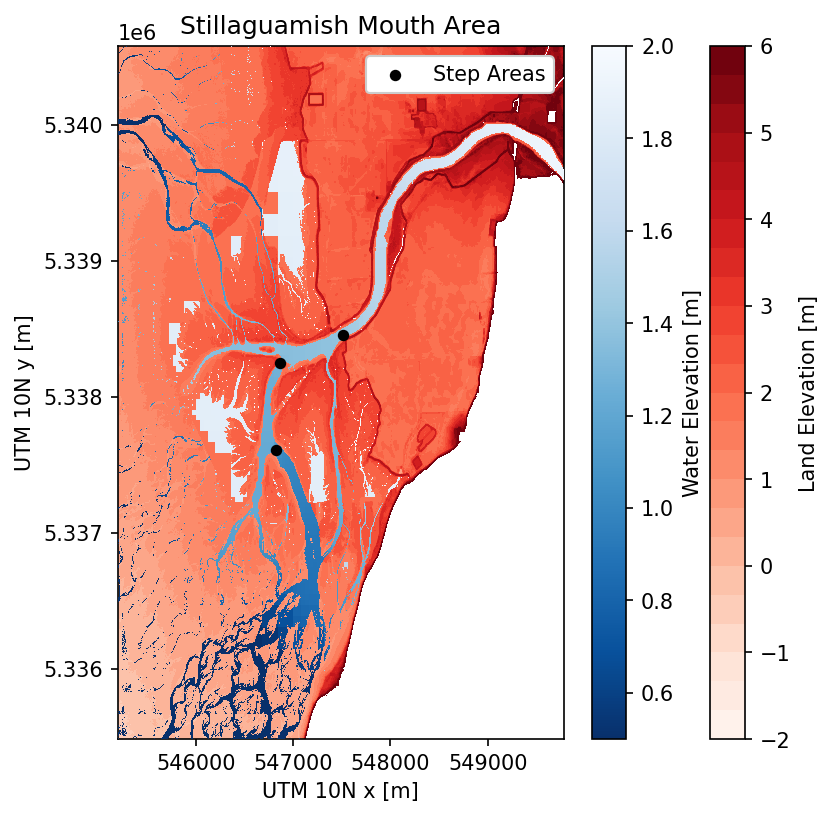

In [258]:
plt.figure(figsize=(6,6), dpi=150)
plt.title("Stillaguamish Mouth Area")
cf = plt.contourf(dem_x[::4], dem_y[::4], dem_z[::4,::4], levels=np.linspace(-2, 6, 25), cmap='Reds', zorder=2)
cb = plt.colorbar(cf)
cb.ax.set_ylabel("Land Elevation [m]")
cf2 = plt.pcolormesh(dem_x, dem_y, eta, cmap='Blues_r', zorder=3, vmin=0.5, vmax=2.0)
cb2 = plt.colorbar(cf2)
cb2.ax.set_ylabel("Water Elevation [m]")
plt.scatter(quad_x[[19, 26, 33]], quad_y[[19, 26, 33]], color='black', s=20, zorder=6, label='Step Areas')
plt.legend(framealpha=1)
plt.xlabel("UTM 10N x [m]")
plt.ylabel("UTM 10N y [m]")
plt.show()

### Let's try a plot along-stream?

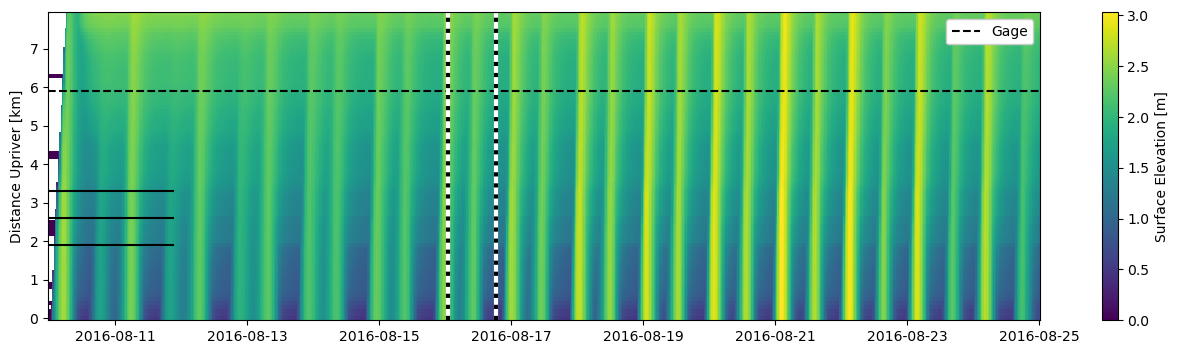

In [266]:
close_lat, close_lon = 48.210927, -122.337067
cx, cy, _, __ = utm.from_latlon(close_lat, close_lon)
i = np.argmin(np.sqrt((quad_x - cx)**2 + (quad_y - cy)**2))

fig = plt.figure(figsize=(16, 4))
m = plt.pcolormesh(out.time, d/1000, zs.T)
cb = plt.colorbar(m)
cb.ax.set_ylabel("Surface Elevation [m]")
plt.ylabel("Distance Upriver [km]")
plt.axhline(d[i]/1000, label='Gage', color='black', linestyle='--')
plt.plot(out.time[[0,int(len(out.time)/8)]], [1.9, 1.9], color='black')
plt.plot(out.time[[0,int(len(out.time)/8)]], [2.6, 2.6], color='black')
plt.plot(out.time[[0,int(len(out.time)/8)]], [3.3, 3.3], color='black')

plt.axvline(out.time.values[325], color='white', linewidth=3)
plt.axvline(out.time.values[325], color='black', linewidth=3, linestyle=':')
plt.axvline(out.time.values[290], color='white', linewidth=3)
plt.axvline(out.time.values[290], color='black', linewidth=3, linestyle=':')

plt.legend(framealpha=1)
plt.show()

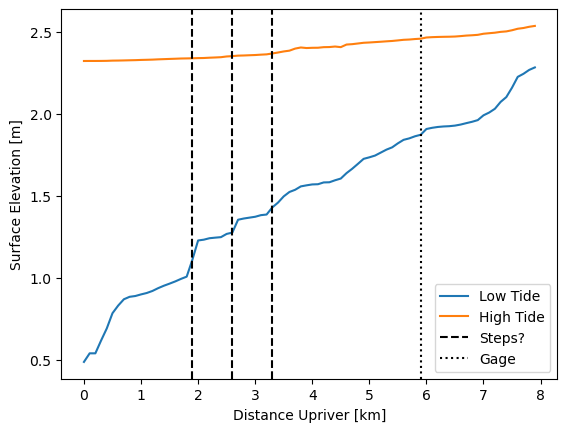

In [267]:
ti = 325

close_lat, close_lon = 48.210927, -122.337067
cx, cy, _, __ = utm.from_latlon(close_lat, close_lon)
i = np.argmin(np.sqrt((quad_x - cx)**2 + (quad_y - cy)**2))


plt.figure()
plt.plot(d/1000, ozs[325,quad_i], label='Low Tide')
plt.plot(d/1000, ozs[290,quad_i], label='High Tide')
plt.axvline(1.9, color='black', linestyle='--')
plt.axvline(2.6, color='black', linestyle='--')
plt.axvline(3.3, color='black', label='Steps?', linestyle='--')
plt.axvline(d[i]/1000, color='black', linestyle=':', label='Gage')
plt.legend()
plt.xlabel("Distance Upriver [km]")
plt.ylabel("Surface Elevation [m]")
plt.show()